In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Set device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Dataset Class
class ActivityDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32).to(device)
        self.labels = torch.tensor(labels, dtype=torch.long).to(device)
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


Using device: mps


In [14]:
class ActivityCNN(nn.Module):
    def __init__(self, num_classes, window_size=10):
        super(ActivityCNN, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv1d(3, 32, kernel_size=3, padding=1)  # 3 input channels
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        
        # Calculate output size after convolutions and pooling
        # After 2 max pooling layers with kernel_size=2, the size is reduced by a factor of 4
        conv_output_size = window_size // 4
        
        # Fully connected layers
        self.fc1 = nn.Linear(64 * conv_output_size, 128)
        self.fc2 = nn.Linear(128, num_classes)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        # First convolutional block
        x = F.relu(self.conv1(x))
        x = F.max_pool1d(x, 2)
        
        # Second convolutional block
        x = F.relu(self.conv2(x))
        x = F.max_pool1d(x, 2)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x


In [15]:
def load_data(file_path, window_size=10):
    print("Loading data...")
    df = pd.read_csv(file_path)
    
    # Sort by timestamp to ensure chronological order
    df = df.sort_values('timestamp')
    
    # Extract labels
    y = df['activity'].values
    
    # Convert string labels to integers
    unique_labels = sorted(set(y))
    label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
    y = np.array([label_to_idx[label] for label in y])
    class_names = unique_labels
    
    # Extract just the x, y, z axis columns
    X_raw = df[['x-axis', 'y-axis', 'z-axis']].values
    
    # Normalize features
    X_raw = (X_raw - X_raw.mean(axis=0)) / (X_raw.std(axis=0) + 1e-8)
    
    # Create sliding windows
    X = []
    y_windowed = []
    
    for i in range(len(X_raw) - window_size + 1):
        window = X_raw[i:i+window_size]
        # Take the most common label in the window
        window_label = np.bincount(y[i:i+window_size]).argmax()
        X.append(window)
        y_windowed.append(window_label)
    
    X = np.array(X)
    y = np.array(y_windowed)
    
    # Reshape for CNN: (samples, channels, sequence_length)
    X = X.transpose(0, 2, 1)  # Reshape to (samples, 3, window_size)
    
    print(f"Data loaded: {X.shape[0]} samples, {X.shape[1]} channels, {X.shape[2]} time steps, {len(class_names)} classes")
    return X, y, class_names


In [16]:
# 4. Train function
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / total
        train_losses.append(train_loss)
        
        # Validation
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_loss = running_loss / len(val_loader.dataset)
        val_acc = correct / total
        val_losses.append(val_loss)
        
        print(f"Epoch {epoch+1}/{epochs} - "
              f"Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f} - "
              f"Val loss: {val_loss:.4f}, Val acc: {val_acc:.4f}")
    
    return train_losses, val_losses



In [17]:
# 5. Evaluate function
def evaluate_model(model, test_loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Calculate accuracy
    accuracy = sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
    
    # Create confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Print results
    print(f"Test Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
    
    return accuracy, cm



Loading data...
Data loaded: 1073614 samples, 3 channels, 10 time steps, 6 classes
Training model...
Epoch 1/10 - Train loss: 0.8334, Train acc: 0.6809 - Val loss: 0.7252, Val acc: 0.7184
Epoch 2/10 - Train loss: 0.7287, Train acc: 0.7180 - Val loss: 0.6773, Val acc: 0.7356
Epoch 3/10 - Train loss: 0.7000, Train acc: 0.7292 - Val loss: 0.6600, Val acc: 0.7399
Epoch 4/10 - Train loss: 0.6836, Train acc: 0.7353 - Val loss: 0.6409, Val acc: 0.7502
Epoch 5/10 - Train loss: 0.6737, Train acc: 0.7394 - Val loss: 0.6398, Val acc: 0.7493
Epoch 6/10 - Train loss: 0.6663, Train acc: 0.7416 - Val loss: 0.6354, Val acc: 0.7512
Epoch 7/10 - Train loss: 0.6611, Train acc: 0.7442 - Val loss: 0.6297, Val acc: 0.7527
Epoch 8/10 - Train loss: 0.6568, Train acc: 0.7458 - Val loss: 0.6281, Val acc: 0.7550
Epoch 9/10 - Train loss: 0.6529, Train acc: 0.7469 - Val loss: 0.6276, Val acc: 0.7535
Epoch 10/10 - Train loss: 0.6493, Train acc: 0.7488 - Val loss: 0.6221, Val acc: 0.7562


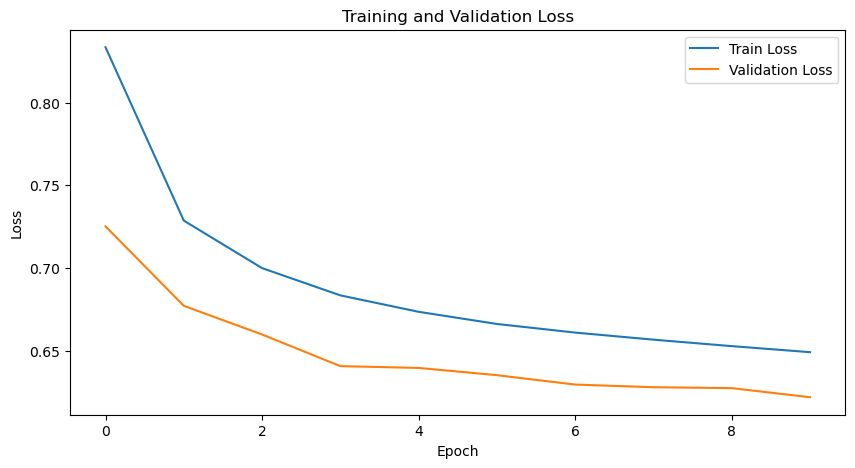


Evaluating model on test data...
Test Accuracy: 0.7584

Classification Report:
              precision    recall  f1-score   support

  Downstairs       0.64      0.31      0.42     18059
     Jogging       0.81      0.86      0.83     52255
     Sitting       0.95      0.93      0.94      7324
    Standing       0.95      0.82      0.88      5056
    Upstairs       0.69      0.44      0.53     17760
     Walking       0.71      0.88      0.79     60589

    accuracy                           0.76    161043
   macro avg       0.79      0.70      0.73    161043
weighted avg       0.75      0.76      0.74    161043



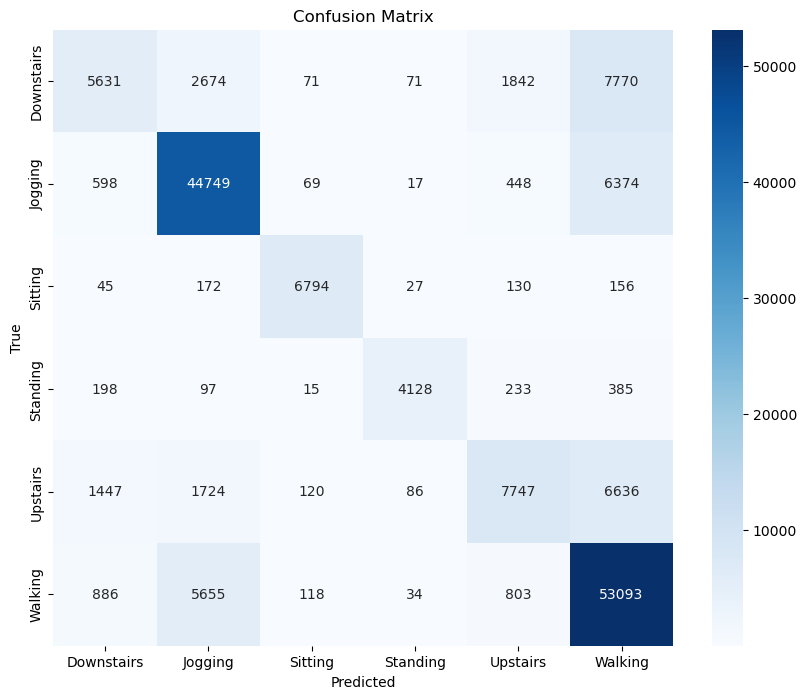

Model saved to activity_recognition_model.pth


In [18]:
def main():
    # Set random seed for reproducibility
    torch.manual_seed(42)
    np.random.seed(42)
    
    # Parameters
    data_path = "/Users/janeyan/Desktop/seminar/project 3/time_series_data_human_activities.csv"
    batch_size = 64
    learning_rate = 0.001
    epochs = 10
    
    # Load data
    X, y, class_names = load_data(data_path)
    num_classes = len(set(y))
    
    # Create dataset
    dataset = ActivityDataset(X, y)
    
    # Split data (70% train, 15% validation, 15% test)
    total_size = len(dataset)
    train_size = int(0.7 * total_size)
    val_size = int(0.15 * total_size)
    test_size = total_size - train_size - val_size
    
    train_dataset, val_dataset, test_dataset = random_split(
        dataset, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    # Initialize model, loss, and optimizer
    model = ActivityCNN(num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # Train model
    print("Training model...")
    train_losses, val_losses = train_model(
        model, train_loader, val_loader, criterion, optimizer, epochs=epochs
    )
    
    # Plot training curves
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.show()
    
    # Evaluate model
    print("\nEvaluating model on test data...")
    accuracy, confusion_matrix = evaluate_model(model, test_loader, class_names)
    
    # Save model
    torch.save(model.state_dict(), 'activity_recognition_model.pth')
    print("Model saved to activity_recognition_model.pth")

if __name__ == "__main__":
    main()
